Carga y exploración del dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Detección de la carpeta donde está guardado el notebook (se encarga de obtener la ruta de windows o de workspace)
folder_path = os.getcwd()
file_name = "superstore_dataset2012.csv"
full_path = os.path.join(folder_path, file_name)
print(f"Archivo CSV encontrado en: {full_path}")

# Configuración para que las gráficas se vean mejor en pantallas pequeñas (como un iPhone)
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# df = pd.read_csv(path, encoding='latin1') # A veces estos CSV requieren codificación latin1

# Cargar en el dataset
df = pd.read_csv(full_path)

# Explorar el dataset
print(df.head(3))
print(df.info())
print(df.describe())

print(f"Columnas con datos vacíos:\n{df.isna().sum()}")
print(f"Total de filas: {len(df)}")
print(f"Filas con datos vacíos:\n{df.isna().any(axis=1).sum()}")

Archivo CSV encontrado en: c:\Users\Goavanni\Documents\Cursos MAVDM\Trabajo4\Ventas_Minoristas1\superstore_dataset2012.csv
   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0   21896   ID-2012-71858   1/2/2012  7/2/2012  Standard Class    CP-12085   
1    4323  MX-2012-154459   1/2/2012  6/2/2012  Standard Class    JF-15190   
2    2829  MX-2012-114461   1/2/2012  5/2/2012  Standard Class    RM-19375   

    Customer Name    Segment       City      State  ...       Product ID  \
0  Cathy Prescott  Corporate    Jakarta    Jakarta  ...  TEC-PH-10003784   
1    Jamie Frazer   Consumer   Santiago   Santiago  ...  TEC-PH-10002102   
2   Raymond Messe   Consumer  Escuintla  Escuintla  ...  TEC-AC-10002760   

     Category Sub-Category                             Product Name     Sales  \
0  Technology       Phones  Motorola Signal Booster, with Caller ID  593.9895   
1  Technology       Phones                  Nokia Headset, Cordless  151.9200   
2  Technology  A

Transformación de fechas

In [23]:
columnas_fechas = ['Order Date', 'Ship Date']
for col in columnas_fechas:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"Tipo de datos en '{col}': {df[col].dtype}")
    print(f"Valores nulos en '{col}': {df[col].isna().sum()}")

Tipo de datos en 'Order Date': datetime64[us]
Valores nulos en 'Order Date': 0
Tipo de datos en 'Ship Date': datetime64[us]
Valores nulos en 'Ship Date': 1411


Visualizaciones univariantes con Matplotlib

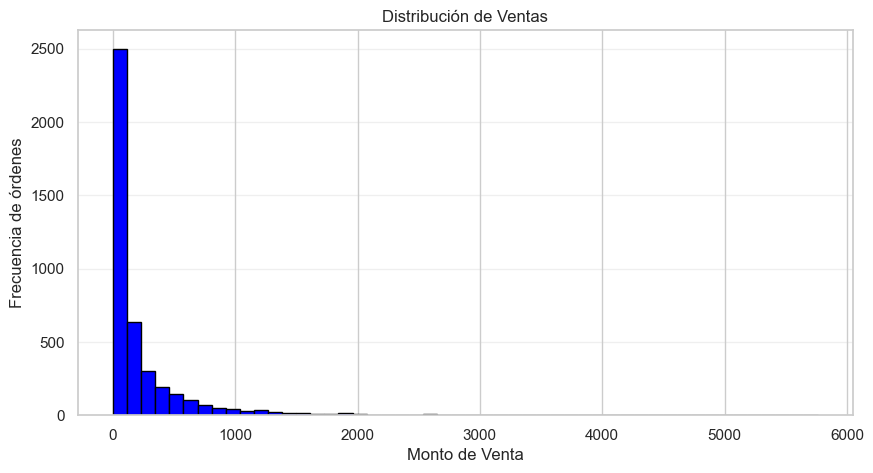

In [24]:
# Creando el histograma de ventas
plt.figure(figsize=(10,5))
plt.hist(df['Sales'], bins=50, color='blue', edgecolor='black') # si se quiere limitar a un rango se agrega: , range=(0, 2000))
plt.title('Distribución de Ventas')
plt.xlabel('Monto de Venta')
plt.ylabel('Frecuencia de órdenes')
plt.grid(axis='y', alpha=0.3)

plt.show()

Visualizaciones univariantes con Seaborn

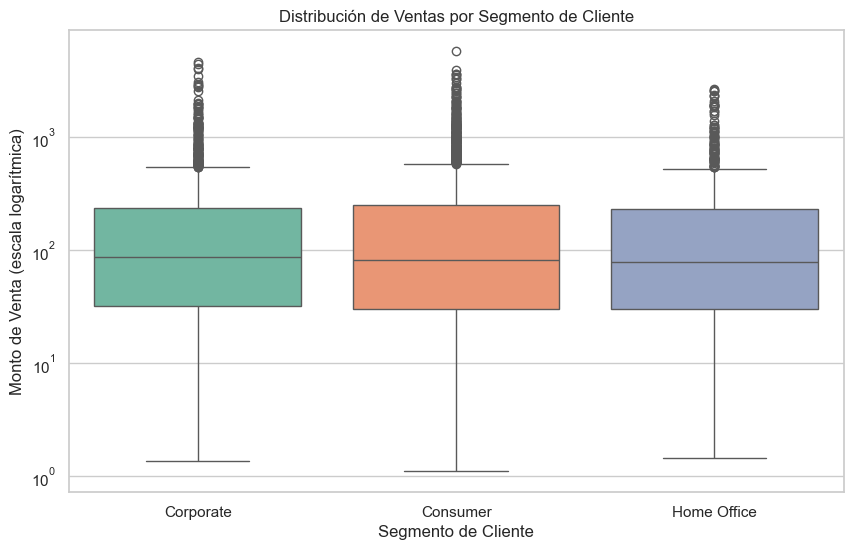

In [26]:
plt.figure(figsize=(10, 6))
# Usamos escala logarítmica en el eje Y para ver mejor la distribución si hay mucha diferencia entre los valores
sns.boxplot(x='Segment', y='Sales', data=df, palette='Set2', hue='Segment',legend=False)
plt.title('Distribución de Ventas por Segmento de Cliente')
plt.yscale('log') # Opcional: ayuda si las ventas varían desde $1 hasta $20,000
plt.xlabel('Segmento de Cliente')
plt.ylabel('Monto de Venta (escala logarítmica)')

plt.show()

Gráficos bivariantes con Matplotlib

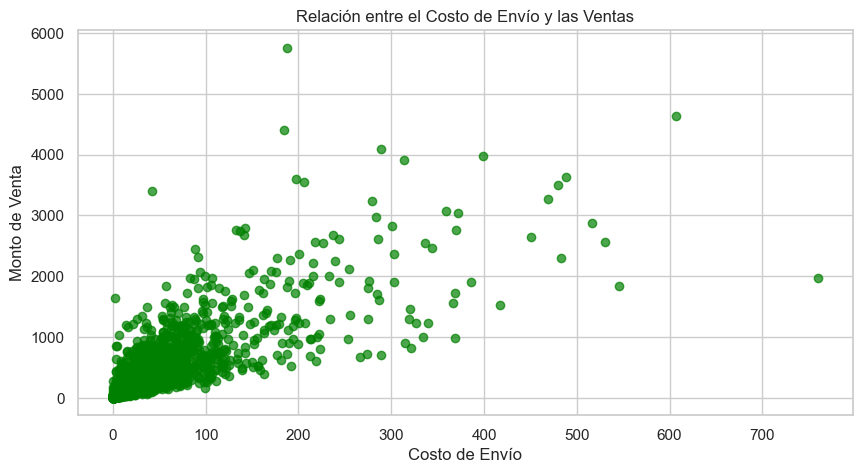

In [35]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Shipping Cost'], df['Sales'], alpha=0.7, color='green')
plt.title('Relación entre el Costo de Envío y las Ventas')
plt.xlabel('Costo de Envío')
plt.ylabel('Monto de Venta')
plt.grid(True)
plt.show()

Gráficos bivariantes con Seaborn

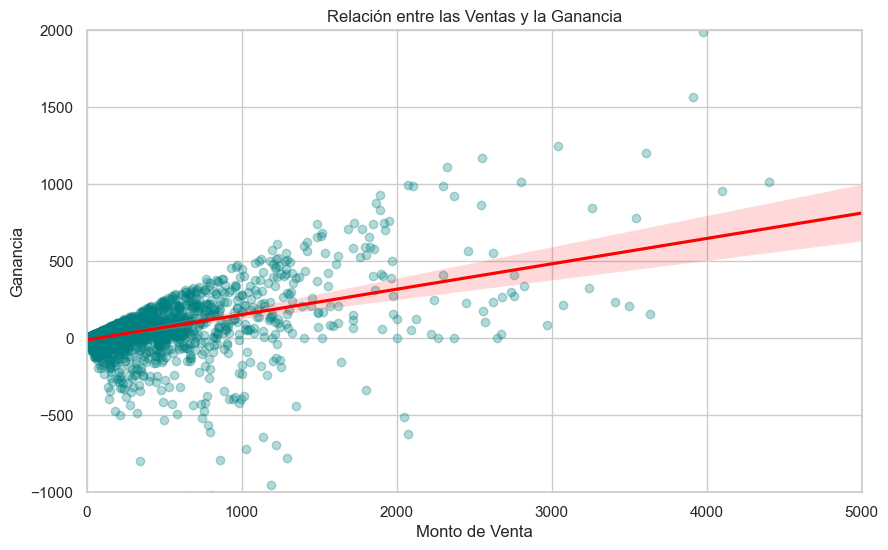

In [32]:
plt.figure(figsize=(10, 6))

# regplot crea la dispersión y la línea de tendencia
sns.regplot(x='Sales', y='Profit', data=df, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Relación entre las Ventas y la Ganancia')
plt.xlabel('Monto de Venta')
plt.ylabel('Ganancia')

# Ajustamos límites para que la gráfica sea legible
plt.xlim(0, 5000)
plt.ylim(-1000, 2000)

plt.show()


Visualización multivariante con Seaborn

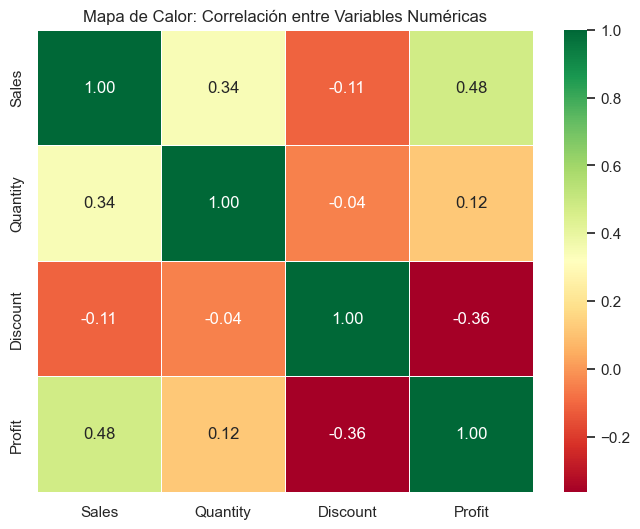

In [38]:
# 1. Seleccion de columnas numéricas para el análisis
# Se requiere asegurar que no haya valores nulos en las columnas numéricas que se van a graficar
df_numerico = df[['Sales', 'Quantity', 'Discount', 'Profit']].dropna()

# 2. Calcular la matriz de correlación
corr_matrix = df_numerico.corr()

# 3. configurar y dibujar el Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

# Personalización
plt.title('Mapa de Calor: Correlación entre Variables Numéricas')
plt.show()